In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import List, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain_community.utilities import GoogleSerperAPIWrapper

from langchain.tools import tool


C:\Users\UseR\AppData\Local\Temp\ipykernel_14880\3069126730.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import GoogleSerperAPIWrapper


In [3]:
class FlowState(BaseModel):
    question : str 
    category : Literal['coding', 'google_search', 'weather'] = Field(default="google_search")
    answer : str = Field(default="")

In [4]:
class QuestionCategory(BaseModel):
    category : Literal['coding', 'google_search', 'weather'] = Field(default="google_search", description="Question Category")

In [5]:
llm = ChatGroq(model="openai/gpt-oss-20b") 

In [8]:
search = GoogleSerperAPIWrapper()
tools = [search.run]

google_agent = create_agent(
    model = llm,
    tools = tools,
    system_prompt= "You are an agent and search for any questions in google."
)

In [12]:
@tool
def get_weather(city:str):
    """It provides real time weather details"""
    return f"the temp in {city} is 20.C"

weather_agent = create_agent(
    model = llm,
    tools = [get_weather],
    system_prompt= "You are an agent and can provide real time weather details."
)

In [13]:
def check_question_category(state:FlowState) -> FlowState:
    #structured output er jonno kora

    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I want to know the category of the question: {state.question}. If you are not sure then just give 'google_search' as a category ")
    state.category = res.category
    return state

In [14]:
def route(state:FlowState) -> Literal['coding', 'google_search', 'weather']:
    return state.category

In [15]:
def coding_node(state:FlowState)-> FlowState:
    res = llm.invoke(f"You are a coding expert: {state.question}")
    state.answer = res.content
    return state

def weather_node(state:FlowState)-> FlowState:
    res =  weather_agent.invoke({"messages": [{"role":"user", "content":state.question}]})
    state.answer = res["messages"][-1].content
    return state

def google_search_node(state:FlowState)-> FlowState:
    res =  google_agent.invoke({"messages": [{"role":"user", "content":state.question}]})
    state.answer = res["messages"][-1].content
    return state

In [16]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("weather", weather_node)
graph.add_node("google_search", google_search_node)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)

In [17]:
graph =  graph.compile()

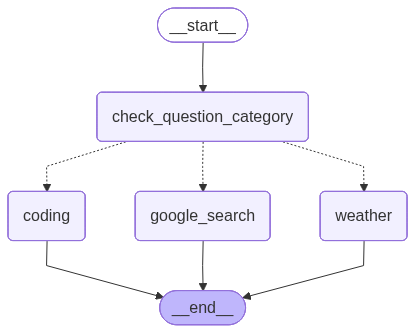

In [18]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [21]:
response = graph.invoke({"question": "What is the name of pm of BD in 2026? Use web search"})
response

{'question': 'What is the name of pm of BD in 2026? Use web search',
 'category': 'google_search',
 'answer': 'The Prime Minister of Bangladesh in 2026 is **Tarique\u202fRahman**【1】.'}